# Phase 2 — Exploratory Data Analysis (EDA)
## Air Quality Intelligence Platform

EDA is the process of systematically interrogating your data before modelling.
Every chart here answers a specific question that will directly inform our
feature engineering and modelling decisions in later phases.

**Questions we will answer:**
1. How healthy is the data? (missing values, types, ranges)
2. How are pollutants distributed? (skew, outliers, normal vs log-normal)
3. When is air quality worst? (hour of day, day of week, season)
4. Which variables are correlated? (sensor vs actual concentration)
5. How does the Italian UCI data compare to live OpenAQ multi-city data?

In [31]:
# ── Standard library ──────────────────────────────────────────────
import os
import warnings

# ── Data manipulation ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # Fine-grained axis tick control
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────
warnings.filterwarnings("ignore")

# Set a consistent, professional visual style for every chart.
# "seaborn-v0_8-whitegrid" gives a clean white background with subtle gridlines.
plt.style.use("seaborn-v0_8-whitegrid")

# Define a colour palette we will reuse throughout every chart.
# Using consistent colours makes the notebook look designed, not accidental.
PALETTE   = "husl"          # Perceptually uniform: all colours look equally vivid
COLOR_CO  = "#E07B54"       # Warm orange → CO (combustion product)
COLOR_NO2 = "#5B8DB8"       # Cool blue  → NO2 (traffic-related)
COLOR_BEN = "#6BAF92"       # Green      → Benzene (organic compound)
COLOR_NOX = "#C97BB2"       # Purple     → NOx (mixed nitrogen oxides)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

# Create the outputs folder if it doesn't exist yet.
# exist_ok=True means "don't crash if it already exists"
os.makedirs("../outputs", exist_ok=True)

print("Setup complete ✓")

Setup complete ✓


In [32]:
# ── Load UCI cleaned dataset ──────────────────────────────────────
# We load from the CSV we saved in Phase 1 (already cleaned).
df = pd.read_csv("../data/raw/uci_air_quality_cleaned.csv")

# Re-parse the DateTime column.
# When pandas writes a datetime to CSV and reads it back, it becomes a
# plain string. pd.to_datetime() converts it back to a datetime object.
# utc=False because the UCI data has no timezone info (it's local Italian time).
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")

# ── Load OpenAQ data ──────────────────────────────────────────────
df_oaq = pd.read_csv("../data/raw/openaq_no2_measurements.csv")

# Re-parse the UTC datetime column — this one has timezone info, so utc=True
df_oaq["datetime_utc"] = pd.to_datetime(df_oaq["datetime_utc"], utc=True, errors="coerce")

print(f"UCI dataset:    {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"OpenAQ dataset: {df_oaq.shape[0]:,} rows × {df_oaq.shape[1]} columns")
print(f"\nUCI date range: {df['DateTime'].min().date()} → {df['DateTime'].max().date()}")
print(f"OpenAQ date range: {df_oaq['datetime_utc'].min().date()} → {df_oaq['datetime_utc'].max().date()}")

UCI dataset:    9,357 rows × 14 columns
OpenAQ dataset: 843 rows × 9 columns

UCI date range: 2004-01-04 → 2005-12-03
OpenAQ date range: 2026-03-11 → 2026-04-09


---
## Section 1 — Data Health Check

Before making any charts, we need to understand what we're working with.
A data health check answers: "Can I trust this data?" and "What needs fixing?"

In [33]:
# Build a descriptive summary table for every column.
# This is far more informative than just printing df.dtypes.

summary_rows = []

for col in df.columns:
    if col == "DateTime":
        # Handle datetime column separately — it has no numeric stats
        summary_rows.append({
            "Column":    col,
            "Dtype":     str(df[col].dtype),
            "Non-null":  df[col].notna().sum(),
            "Missing %": round(df[col].isna().mean() * 100, 1),
            "Min":       str(df[col].min().date()),
            "Max":       str(df[col].max().date()),
            "Mean":      "—",
            "Std":       "—"
        })
    else:
        col_data = pd.to_numeric(df[col], errors="coerce")
        # pd.to_numeric with errors="coerce" converts anything non-numeric to NaN.
        # We call it here to be safe, in case any column still has stray strings.
        summary_rows.append({
            "Column":    col,
            "Dtype":     str(df[col].dtype),
            "Non-null":  col_data.notna().sum(),
            "Missing %": round(col_data.isna().mean() * 100, 1),
            "Min":       round(col_data.min(), 2) if col_data.notna().any() else "—",
            "Max":       round(col_data.max(), 2) if col_data.notna().any() else "—",
            "Mean":      round(col_data.mean(), 2) if col_data.notna().any() else "—",
            "Std":       round(col_data.std(), 2) if col_data.notna().any() else "—"
        })

df_schema = pd.DataFrame(summary_rows)
# style.set_properties sets visual formatting on the displayed table.
# This only affects notebook display, not the underlying data.
df_schema.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Column,Dtype,Non-null,Missing %,Min,Max,Mean,Std
CO(GT),float64,7674,18.000000,0.100000,11.900000,2.150000,1.450000
PT08.S1(CO),float64,8991,3.900000,647.250000,2039.750000,1099.710000,217.080000
NMHC(GT),float64,914,90.200000,7.000000,1189.000000,218.810000,204.460000
C6H6(GT),float64,8991,3.900000,0.150000,63.740000,10.080000,7.450000
PT08.S2(NMHC),float64,8991,3.900000,383.250000,2214.000000,939.030000,266.830000
NOx(GT),float64,7718,17.500000,2.000000,1479.000000,246.880000,212.970000
PT08.S3(NOx),float64,8991,3.900000,322.000000,2682.750000,835.370000,256.820000
NO2(GT),float64,7715,17.500000,2.000000,339.700000,113.080000,48.360000
PT08.S4(NO2),float64,8991,3.900000,551.000000,2775.000000,1456.140000,346.200000
PT08.S5(O3),float64,8991,3.900000,221.000000,2522.750000,1022.780000,398.480000


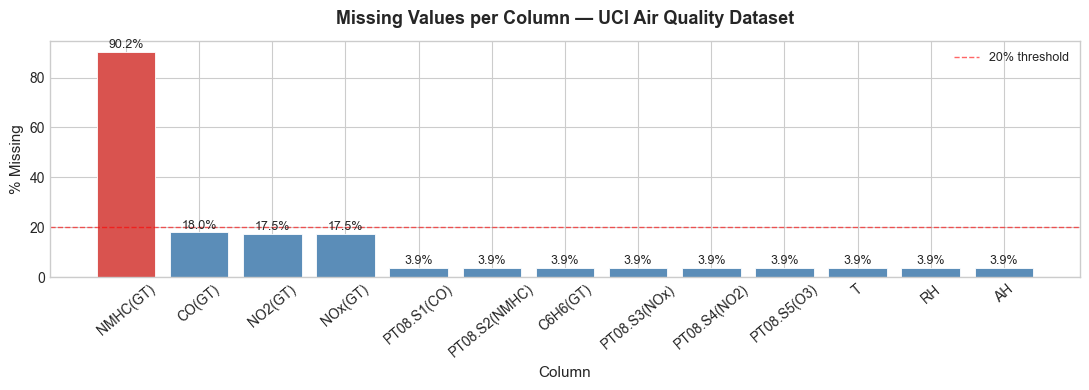


Key observation:
NMHC(GT) has very high missingness — we will drop it in Phase 3.
Other columns have moderate missingness that we will impute.


In [34]:
# Calculate missing percentage for numeric columns only
# (DateTime is always present so we exclude it for clarity)
numeric_cols = [c for c in df.columns if c != "DateTime"]

missing_pct = (
    df[numeric_cols]
    .isnull()          # Boolean DataFrame: True where value is missing
    .mean()            # Mean of booleans = fraction missing (True=1, False=0)
    .mul(100)          # Convert fraction to percentage
    .sort_values(ascending=False)  # Highest missing % first
)

# Only plot columns that actually have missing values
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(11, 4))

# sns.barplot draws bars with an optional confidence interval.
# x= and y= take column names when we pass a DataFrame to data=,
# OR they take array-like values when we don't pass data=.
# Here we pass the index (column names) and values directly.
bars = ax.bar(
    missing_pct.index,
    missing_pct.values,
    color=["#d9534f" if v > 20 else "#5b8db8" for v in missing_pct.values],
    # List comprehension: red if >20% missing (problematic), blue otherwise
    edgecolor="white",
    linewidth=0.6
)

# Add a horizontal reference line at 20% — our "concern threshold"
ax.axhline(20, color="red", linestyle="--", linewidth=1, alpha=0.6, label="20% threshold")

# Annotate each bar with its exact percentage
for bar, val in zip(bars, missing_pct.values):
    # bar.get_x() = left edge x position of the bar
    # bar.get_width() = width of the bar
    # bar.get_x() + bar.get_width()/2 = centre of the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,          # Slightly above the bar top
        f"{val:.1f}%",      # Format: one decimal place, percent sign
        ha="center",        # Horizontal alignment: centred on x position
        va="bottom",        # Vertical alignment: text baseline at bottom
        fontsize=9
    )

ax.set_title("Missing Values per Column — UCI Air Quality Dataset", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Column", fontsize=11)
ax.set_ylabel("% Missing", fontsize=11)
ax.tick_params(axis="x", rotation=40)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/02_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey observation:")
print("NMHC(GT) has very high missingness — we will drop it in Phase 3.")
print("Other columns have moderate missingness that we will impute.")

---
## Section 2 — Distributions

**Why distributions matter for machine learning:**
A model trained on skewed data performs poorly because it has seen
many "normal" examples and very few extreme ones. Understanding the
shape of each variable tells us whether we need to apply log transforms,
cap outliers, or treat them as special cases.

**What to look for:**
- **Normal (bell curve)**: Temperature, humidity — balanced, centred
- **Right-skewed**: Most pollutants — many low values, rare extreme spikes
- **Bimodal (two humps)**: Could indicate two different operating conditions
  (e.g. day vs night, weekday vs weekend)

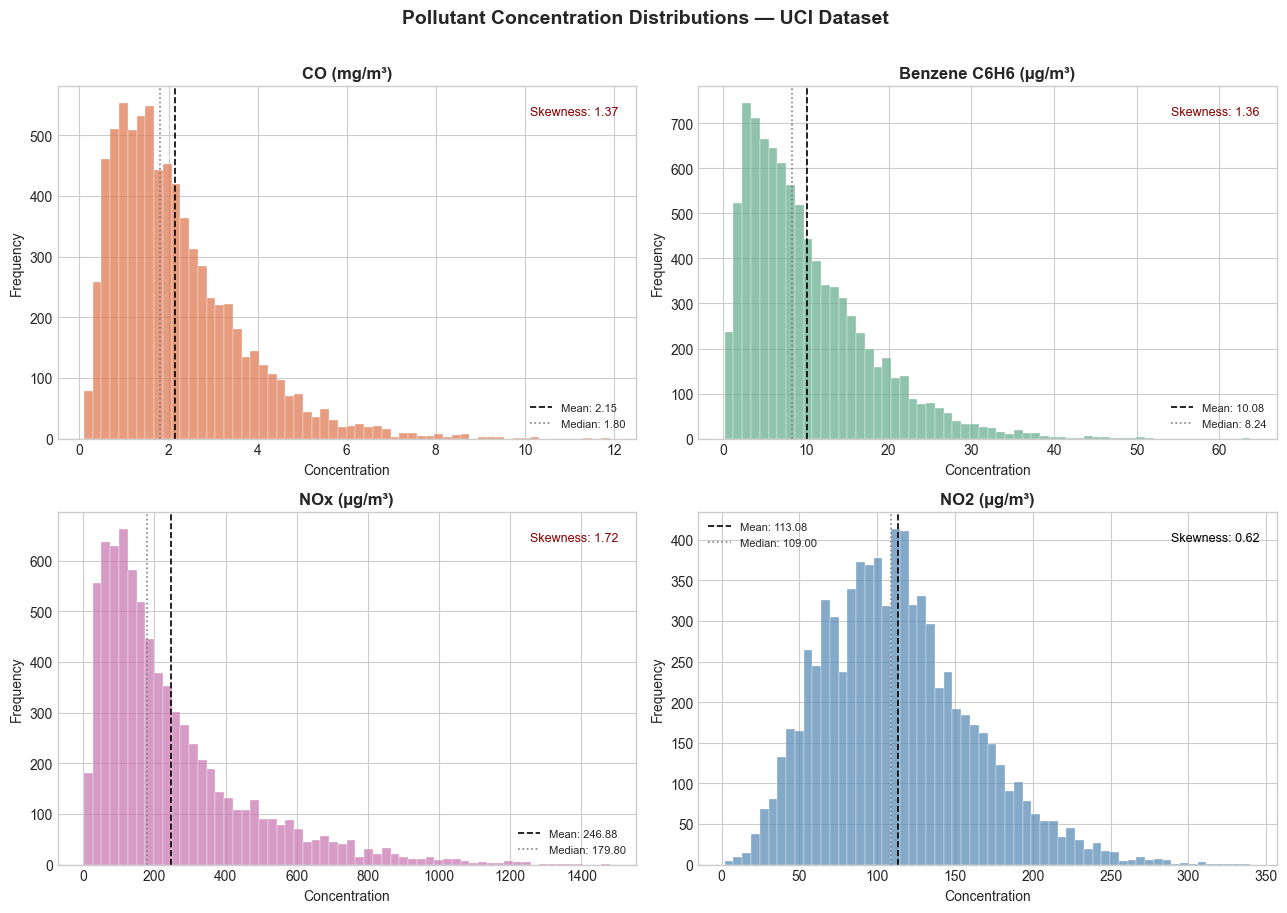


Key observations:
  CO (mg/m³)                 skew=1.37  mean=2.15  max=11.90
  Benzene C6H6 (µg/m³)       skew=1.36  mean=10.08  max=63.74
  NOx (µg/m³)                skew=1.72  mean=246.88  max=1479.00
  NO2 (µg/m³)                skew=0.62  mean=113.08  max=339.70


In [35]:
# Select the actual-concentration columns (GT = Ground Truth, from reference analyser)
# We exclude the PT08 sensor response columns for now (those are indirect proxies)
pollutant_cols = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
pollutant_labels = ["CO (mg/m³)", "Benzene C6H6 (µg/m³)", "NOx (µg/m³)", "NO2 (µg/m³)"]
pollutant_colors = [COLOR_CO, COLOR_BEN, COLOR_NOX, COLOR_NO2]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# plt.subplots(rows, cols) creates a grid of subplots.
# axes is now a 2×2 numpy array; axes[0,0] is top-left, axes[1,1] is bottom-right.

# axes.flatten() converts the 2D array to a 1D list [ax00, ax01, ax10, ax11]
# so we can loop over them with zip() alongside our column lists.
for ax, col, label, color in zip(axes.flatten(), pollutant_cols, pollutant_labels, pollutant_colors):

    # Get the clean numeric values for this column
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    # dropna() removes NaN values so they don't appear as 0-bin entries

    # ── Main histogram ────────────────────────────────────────────
    ax.hist(
        values,
        bins=60,          # Number of histogram bars — more bins = finer detail
        color=color,
        alpha=0.75,       # Slight transparency so overlapping bars are visible
        edgecolor="white",
        linewidth=0.3
    )

    # ── Add a vertical line at the mean ──────────────────────────
    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(mean_val,   color="black",  linestyle="--", linewidth=1.2,
               label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color="gray",   linestyle=":",  linewidth=1.2,
               label=f"Median: {median_val:.2f}")
    # When mean > median, the distribution is right-skewed.
    # This is typical for pollutants — most readings are low but rare
    # pollution events create a long right tail.

    # ── Skewness annotation ───────────────────────────────────────
    skewness = values.skew()
    # .skew() computes the statistical skewness:
    #   0 = perfectly symmetric
    #  >0 = right-skewed (long tail to the right)
    #  <0 = left-skewed (long tail to the left)
    # Values > 1 or < -1 are considered highly skewed.

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Concentration", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend(fontsize=8)

    # Place the skewness value in the top-right corner of the chart
    ax.text(
        0.97, 0.92,                  # x=97%, y=92% of axis dimensions
        f"Skewness: {skewness:.2f}",
        transform=ax.transAxes,      # Coordinates relative to axes (0–1 scale)
        ha="right",                  # Right-aligned
        fontsize=9,
        color="darkred" if abs(skewness) > 1 else "black"
        # Red text if highly skewed — calls attention to it
    )

fig.suptitle("Pollutant Concentration Distributions — UCI Dataset", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/02_pollutant_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey observations:")
for col, label in zip(pollutant_cols, pollutant_labels):
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    print(f"  {label:25s}  skew={vals.skew():.2f}  mean={vals.mean():.2f}  max={vals.max():.2f}")

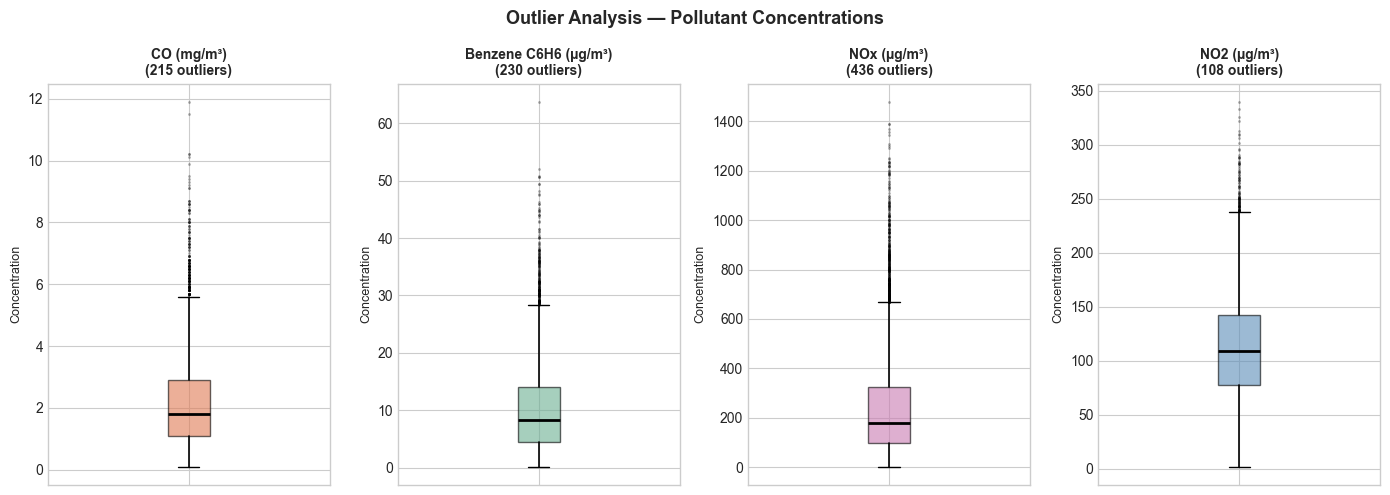


Outliers will be investigated — some are real pollution events,
others may be sensor malfunctions. We will cap them at the 99th percentile in Phase 3.


In [36]:
# Boxplots show the median, interquartile range (IQR), and outliers.
# The "whiskers" extend to 1.5×IQR — anything beyond is plotted as a dot (outlier).
# IQR = Q3 - Q1 (the middle 50% of the data)

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
# 1 row, 4 columns — one boxplot per pollutant

for ax, col, label, color in zip(axes, pollutant_cols, pollutant_labels, pollutant_colors):
    values = pd.to_numeric(df[col], errors="coerce").dropna()

    # Create the boxplot using matplotlib directly (more control than seaborn here)
    bp = ax.boxplot(
        values,
        patch_artist=True,    # Fill the box with colour (not just outline)
        medianprops=dict(color="black", linewidth=2),
        # medianprops: dictionary of styling for the median line
        boxprops=dict(facecolor=color, alpha=0.6),
        # boxprops: styling for the box itself
        whiskerprops=dict(linewidth=1.2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3, color=color)
        # flierprops: styling for outlier dots
        # alpha=0.3 makes the many outlier dots semi-transparent so they
        # don't form a solid mass
    )

    # Count how many outliers there are (beyond the whiskers)
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    # quantile(0.25) = the value below which 25% of readings fall
    # quantile(0.75) = the value below which 75% of readings fall
    iqr = q3 - q1
    # IQR = Interquartile Range — the spread of the middle 50% of values
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    # The "fences" define the whisker endpoints.
    # Anything outside these fences is an outlier.
    n_outliers = ((values < lower_fence) | (values > upper_fence)).sum()
    # | is bitwise OR in pandas boolean conditions
    # This counts rows where the value is below the lower fence OR above the upper fence

    ax.set_title(f"{label}\n({n_outliers} outliers)", fontsize=10, fontweight="bold")
    ax.set_xticklabels([])   # Remove x-axis labels (they're just "1" for each box)
    ax.set_ylabel("Concentration", fontsize=9)

fig.suptitle("Outlier Analysis — Pollutant Concentrations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/02_boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nOutliers will be investigated — some are real pollution events,")
print("others may be sensor malfunctions. We will cap them at the 99th percentile in Phase 3.")

---
## Section 3 — Time Patterns

**This is the most important section for understanding air quality.**

Air pollution is fundamentally a time-series phenomenon driven by:
- **Hour of day**: Rush-hour traffic → peaks at 8am and 6pm
- **Day of week**: Weekdays have more traffic than weekends
- **Season**: Temperature inversions trap pollution in winter

Finding these patterns now means we will engineer them as features
(hour, day_of_week, is_weekend, month) in Phase 3 — and they will
likely be among the most important features in our model.

In [37]:
# Before we can plot by hour/day/month, we need to extract those
# components from the DateTime column.

# ── Add derived time columns ──────────────────────────────────────
df["Hour"]       = df["DateTime"].dt.hour
# .dt is pandas' datetime accessor — gives access to datetime components.
# .dt.hour extracts the hour (0–23) from each timestamp.

df["DayOfWeek"]  = df["DateTime"].dt.dayofweek
# .dt.dayofweek returns 0=Monday, 1=Tuesday, ..., 6=Sunday
# This is a useful convention — Monday is the start of the work week.

df["Month"]      = df["DateTime"].dt.month
# .dt.month extracts the month number (1=January ... 12=December)

df["DayName"]    = df["DateTime"].dt.day_name()
# .dt.day_name() returns the full name: "Monday", "Tuesday", etc.
# Useful for chart labels.

df["MonthName"]  = df["DateTime"].dt.month_name()
# Returns "January", "February", etc.

df["IsWeekend"]  = df["DayOfWeek"] >= 5
# Monday=0 ... Friday=4, Saturday=5, Sunday=6
# So DayOfWeek >= 5 is True for weekend, False for weekday.
# This boolean column will become a binary feature later.

# Confirm the new columns were added
print("New time columns added:")
print(df[["DateTime", "Hour", "DayOfWeek", "DayName", "Month", "IsWeekend"]].head(8))

New time columns added:
             DateTime  Hour  DayOfWeek DayName  Month  IsWeekend
0 2004-01-04 00:00:00 0.000      6.000  Sunday  1.000       True
1 2004-01-04 01:00:00 1.000      6.000  Sunday  1.000       True
2 2004-01-04 02:00:00 2.000      6.000  Sunday  1.000       True
3 2004-01-04 03:00:00 3.000      6.000  Sunday  1.000       True
4 2004-01-04 04:00:00 4.000      6.000  Sunday  1.000       True
5 2004-01-04 05:00:00 5.000      6.000  Sunday  1.000       True
6 2004-01-04 06:00:00 6.000      6.000  Sunday  1.000       True
7 2004-01-04 07:00:00 7.000      6.000  Sunday  1.000       True


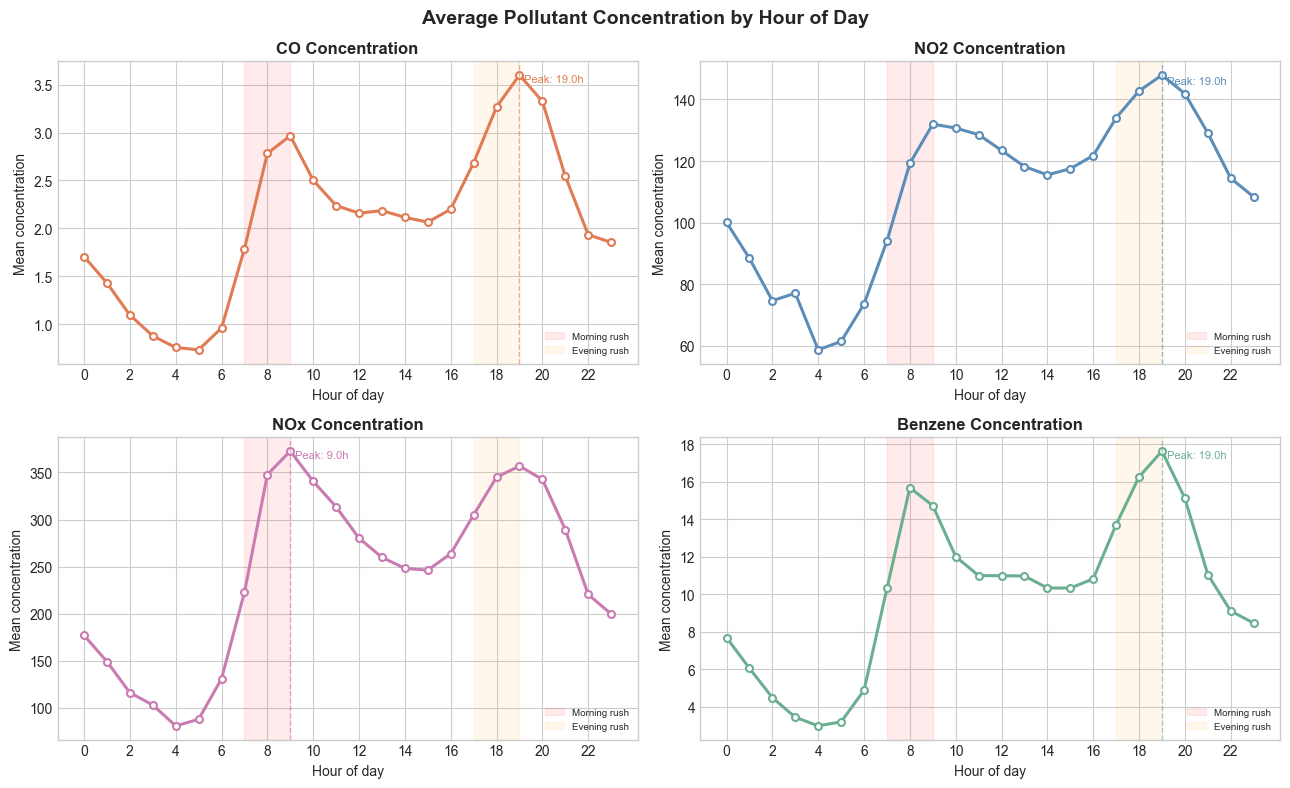


Key finding: pollution peaks during morning rush hour (7–9am) for most pollutants.
This confirms traffic as the main driver — a key insight for our model.


In [38]:
# For each hour of the day (0–23), compute the mean CO and NO2 concentration.
# This reveals the rush-hour pollution signature.

# We must convert these to numeric first for the groupby to work correctly.
df["CO_num"]  = pd.to_numeric(df["CO(GT)"],  errors="coerce")
df["NO2_num"] = pd.to_numeric(df["NO2(GT)"], errors="coerce")
df["NOx_num"] = pd.to_numeric(df["NOx(GT)"], errors="coerce")
df["Ben_num"] = pd.to_numeric(df["C6H6(GT)"],errors="coerce")

# groupby("Hour") splits the DataFrame into 24 groups (one per hour).
# .mean() computes the average value within each group.
# The result is a new DataFrame indexed by Hour (0–23).
hourly = df.groupby("Hour")[["CO_num", "NO2_num", "NOx_num", "Ben_num"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_configs = [
    ("CO_num",  "CO Concentration",      COLOR_CO),
    ("NO2_num", "NO2 Concentration",     COLOR_NO2),
    ("NOx_num", "NOx Concentration",     COLOR_NOX),
    ("Ben_num", "Benzene Concentration", COLOR_BEN),
]

for ax, (col, title, color) in zip(axes.flatten(), plot_configs):
    ax.plot(
        hourly.index,        # x-axis: hours 0–23
        hourly[col],         # y-axis: mean concentration
        color=color,
        linewidth=2.2,
        marker="o",          # Draw a dot at each hourly data point
        markersize=5,
        markerfacecolor="white",    # White dot interior
        markeredgecolor=color,      # Coloured dot border
        markeredgewidth=1.5
    )

    # Shade the background to mark typical rush hours
    # axvspan fills a vertical band between x1 and x2.
    ax.axvspan(7, 9,   alpha=0.08, color="red",  label="Morning rush")
    ax.axvspan(17, 19, alpha=0.08, color="orange", label="Evening rush")

    # Mark the peak hour with a dashed vertical line
    peak_hour = hourly[col].idxmax()
    # .idxmax() returns the INDEX (hour number) of the maximum value
    ax.axvline(peak_hour, color=color, linestyle="--", linewidth=1, alpha=0.6)
    ax.text(peak_hour + 0.2, hourly[col].max() * 0.98,
            f"Peak: {peak_hour}h", fontsize=8, color=color)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Hour of day", fontsize=10)
    ax.set_ylabel("Mean concentration", fontsize=10)
    ax.set_xticks(range(0, 24, 2))   # Show tick marks every 2 hours
    ax.legend(fontsize=7, loc="lower right")

fig.suptitle("Average Pollutant Concentration by Hour of Day", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/02_hourly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey finding: pollution peaks during morning rush hour (7–9am) for most pollutants.")
print("This confirms traffic as the main driver — a key insight for our model.")

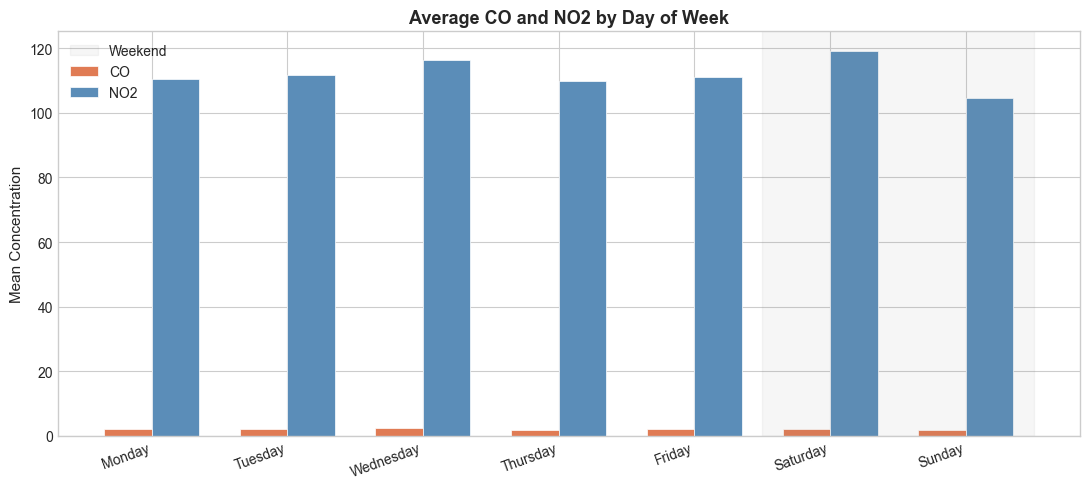


Key finding: weekdays show higher pollution than weekends —
confirming commuter traffic as a primary driver.


In [39]:
# Order the days correctly (Mon → Sun) for the chart
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekly = (
    df.groupby("DayName")[["CO_num", "NO2_num"]]
    .mean()
    .reindex(day_order)   # Reorder rows to match our day_order list
    # Without reindex(), groupby sorts alphabetically ("Friday" before "Monday")
)

fig, ax = plt.subplots(figsize=(11, 5))

x = range(len(day_order))   # [0, 1, 2, 3, 4, 5, 6] — x positions for bars

bar_width = 0.35   # Each bar is 35% of the available space

# Plot CO bars slightly to the left of centre, NO2 bars to the right.
# This is a "grouped bar chart".
bars_co = ax.bar(
    [i - bar_width/2 for i in x],   # Shift left by half bar width
    weekly["CO_num"],
    width=bar_width,
    color=COLOR_CO,
    label="CO",
    edgecolor="white",
    linewidth=0.5
)
bars_no2 = ax.bar(
    [i + bar_width/2 for i in x],   # Shift right by half bar width
    weekly["NO2_num"],
    width=bar_width,
    color=COLOR_NO2,
    label="NO2",
    edgecolor="white",
    linewidth=0.5
)

# Shade the weekend background
ax.axvspan(4.5, 6.5, alpha=0.07, color="gray", label="Weekend")
# 4.5 is between Friday(4) and Saturday(5), 6.5 is after Sunday(6)

ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=20, ha="right")
# ha="right" aligns the rotated labels to the right of the tick mark
ax.set_title("Average CO and NO2 by Day of Week", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Concentration", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/02_weekly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey finding: weekdays show higher pollution than weekends —")
print("confirming commuter traffic as a primary driver.")

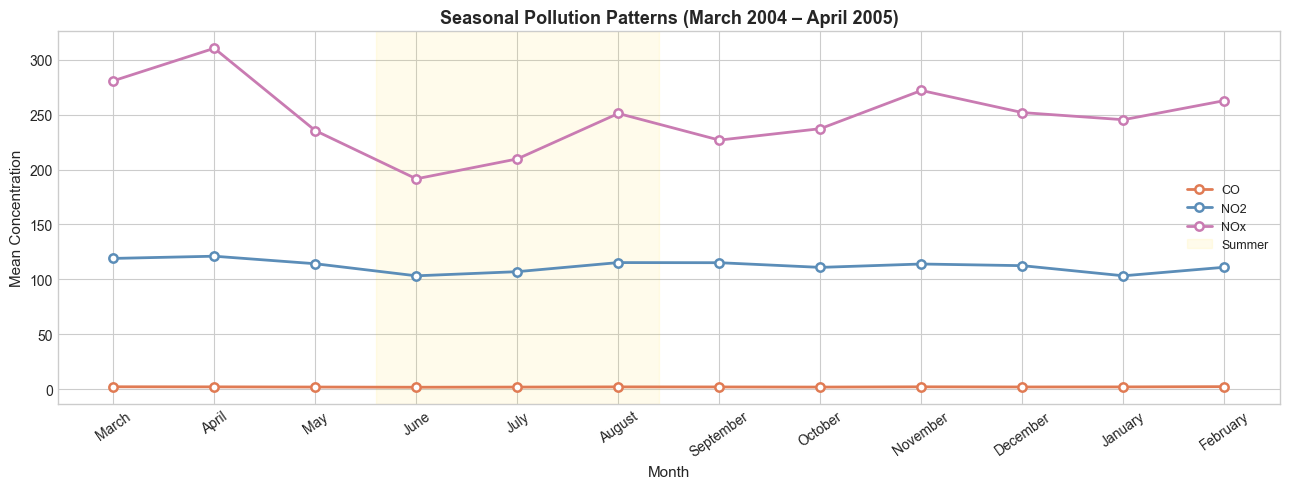


Key finding: pollution dips in summer (better ventilation, less heating)
and rises in autumn/winter — temperature inversions trap pollutants near ground level.


In [40]:
month_order = ["March","April","May","June","July","August",
               "September","October","November","December",
               "January","February"]
# The UCI data runs March 2004 → April 2005. We manually order months
# to show the actual chronological progression.

monthly = (
    df.groupby("MonthName")[["CO_num", "NO2_num", "NOx_num"]]
    .mean()
    .reindex([m for m in month_order if m in df["MonthName"].unique()])
    # Only include months actually present in the dataset
)

fig, ax = plt.subplots(figsize=(13, 5))

for col, color, label in [
    ("CO_num",  COLOR_CO,  "CO"),
    ("NO2_num", COLOR_NO2, "NO2"),
    ("NOx_num", COLOR_NOX, "NOx")
]:
    ax.plot(
        monthly.index,
        monthly[col],
        marker="o", linewidth=2, markersize=6,
        color=color, label=label,
        markerfacecolor="white", markeredgewidth=1.8
    )

# Shade summer months (June–August) to highlight seasonal dip
summer_months = [m for m in monthly.index if m in ["June","July","August"]]
if len(summer_months) >= 2:
    start_idx = list(monthly.index).index(summer_months[0])
    end_idx   = list(monthly.index).index(summer_months[-1])
    ax.axvspan(start_idx - 0.4, end_idx + 0.4,
               alpha=0.08, color="gold", label="Summer")

ax.set_title("Seasonal Pollution Patterns (March 2004 – April 2005)", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Concentration", fontsize=11)
ax.set_xlabel("Month", fontsize=11)
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/02_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey finding: pollution dips in summer (better ventilation, less heating)")
print("and rises in autumn/winter — temperature inversions trap pollutants near ground level.")

---
## Section 4 — Correlations

A correlation measures how strongly two variables move together.
- **+1.0**: Perfect positive correlation (when X goes up, Y goes up)
- **0.0**: No linear relationship
- **-1.0**: Perfect negative correlation (when X goes up, Y goes down)

**Why this matters for our model:**
The PT08 columns are metal-oxide sensor responses — indirect proxies for
the actual pollutant concentrations. If PT08.S1 strongly correlates with
CO(GT), it's a good feature for predicting CO. The correlation matrix
tells us which sensors are genuinely informative vs redundant.

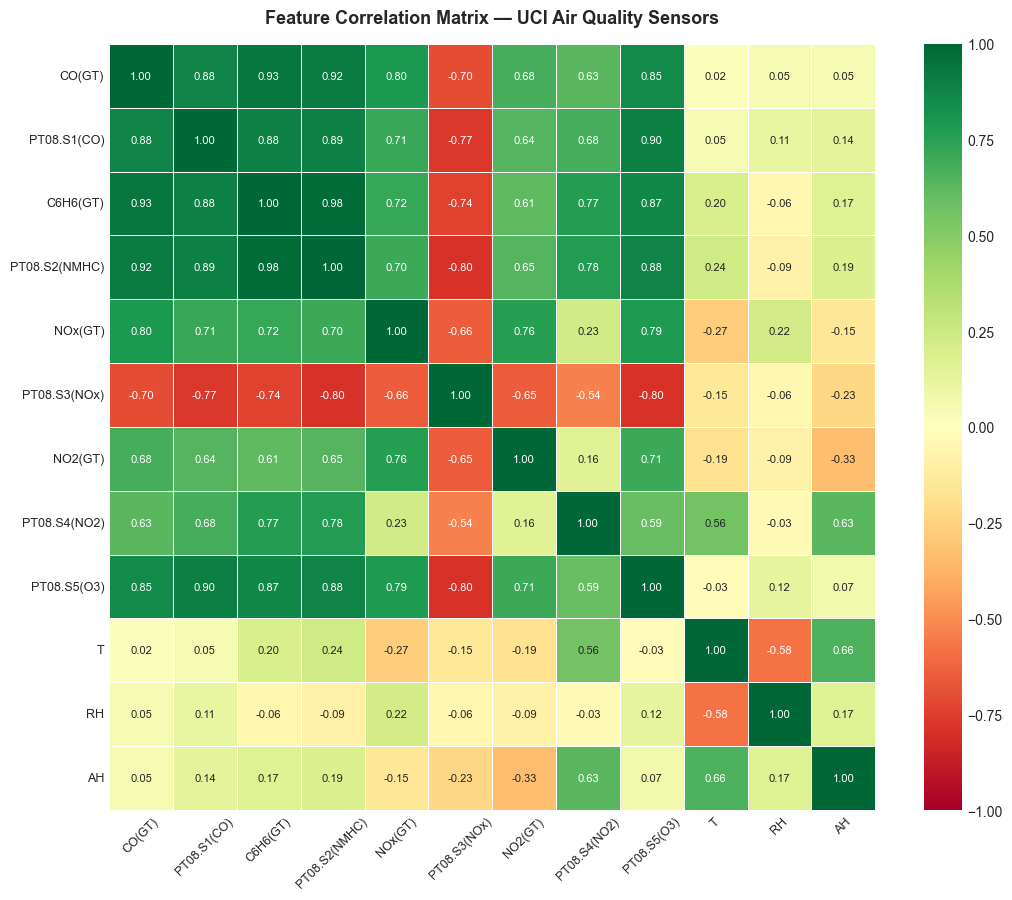


Top 10 most correlated variable pairs:
   Variable 1    Variable 2  Correlation
     C6H6(GT) PT08.S2(NMHC)        0.982
       CO(GT)      C6H6(GT)        0.931
       CO(GT) PT08.S2(NMHC)        0.916
  PT08.S1(CO)   PT08.S5(O3)        0.899
  PT08.S1(CO) PT08.S2(NMHC)        0.893
  PT08.S1(CO)      C6H6(GT)        0.884
PT08.S2(NMHC)   PT08.S5(O3)        0.881
       CO(GT)   PT08.S1(CO)        0.879
     C6H6(GT)   PT08.S5(O3)        0.866
       CO(GT)   PT08.S5(O3)        0.854


In [41]:
# Select the numeric sensor and pollutant columns
corr_cols = [
    "CO(GT)", "PT08.S1(CO)",
    "C6H6(GT)", "PT08.S2(NMHC)",
    "NOx(GT)", "PT08.S3(NOx)",
    "NO2(GT)", "PT08.S4(NO2)",
    "PT08.S5(O3)", "T", "RH", "AH"
]

# Convert all to numeric (in case any are still strings)
df_corr = df[corr_cols].apply(pd.to_numeric, errors="coerce")
# .apply(function) applies a function to each column.
# pd.to_numeric with errors="coerce" converts to number or NaN.

# .corr() computes the Pearson correlation coefficient between every
# pair of columns. The result is a symmetric matrix — corr[A][B] == corr[B][A].
# Pearson correlation measures LINEAR relationships only.
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))

# sns.heatmap draws the correlation matrix as a colour grid.
# annot=True: write the correlation number inside each cell
# fmt=".2f": format numbers to 2 decimal places
# cmap="RdYlGn": Red (negative) → Yellow (zero) → Green (positive)
# linewidths: thin lines between cells for readability
# vmin/vmax: force the colour scale to go from -1 to +1
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.4,
    linecolor="white",
    vmin=-1, vmax=1,
    annot_kws={"size": 8},   # Font size for the numbers inside cells
    square=True              # Make each cell square (not rectangular)
)

ax.set_title("Feature Correlation Matrix — UCI Air Quality Sensors",
             fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("../outputs/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the top correlated pairs
print("\nTop 10 most correlated variable pairs:")
# Get upper triangle of correlation matrix only (avoid duplicates)
corr_upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    # np.triu creates a matrix of 1s in the upper triangle (above diagonal).
    # k=1 excludes the diagonal itself (a variable is always corr=1 with itself).
    # .astype(bool) converts 1→True, 0→False for use as a mask.
)
# Stack converts the 2D matrix to a Series of (col1, col2) → value pairs
top_pairs = (
    corr_upper.stack()             # Flatten to a Series
    .reset_index()                 # Convert index to columns
    .rename(columns={"level_0": "Variable 1", "level_1": "Variable 2", 0: "Correlation"})
    .sort_values("Correlation", ascending=False, key=abs)
    # key=abs sorts by absolute value — catches both strong positive and negative correlations
    .head(10)
)
print(top_pairs.to_string(index=False))

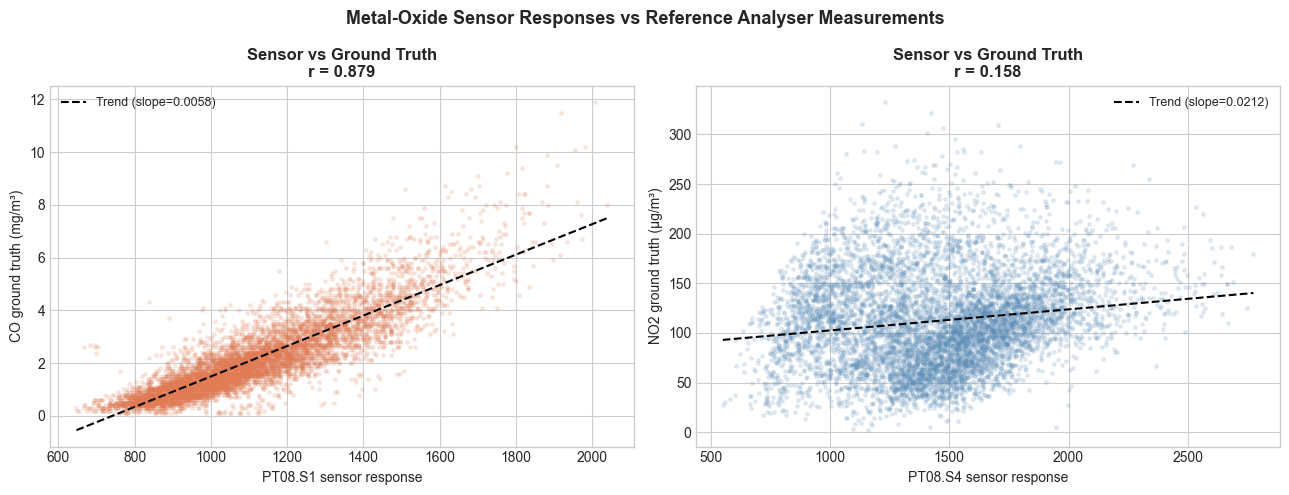

In [42]:
# One of the key questions: "How well does the PT08 metal-oxide sensor
# actually track the true pollutant concentration?"
# A scatter plot of sensor response vs ground-truth concentration answers this directly.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sensor_pairs = [
    ("PT08.S1(CO)",  "CO(GT)",  "PT08.S1 sensor response", "CO ground truth (mg/m³)", COLOR_CO),
    ("PT08.S4(NO2)", "NO2(GT)", "PT08.S4 sensor response", "NO2 ground truth (µg/m³)", COLOR_NO2),
]

for ax, (x_col, y_col, x_label, y_label, color) in zip(axes, sensor_pairs):
    x_vals = pd.to_numeric(df[x_col], errors="coerce")
    y_vals = pd.to_numeric(df[y_col], errors="coerce")

    # Create a mask: only rows where BOTH columns have valid values
    mask = x_vals.notna() & y_vals.notna()
    # & is bitwise AND on boolean Series — both must be True

    ax.scatter(
        x_vals[mask],
        y_vals[mask],
        alpha=0.15,          # Low alpha — many overlapping points become a density cloud
        s=6,                 # Point size (s= for scatter)
        color=color,
        rasterized=True      # Render as pixels, not vector paths — speeds up large scatter plots
    )

    # Compute and plot a trend line using numpy's polyfit
    # np.polyfit(x, y, deg=1) fits a line (degree 1 polynomial) to the data.
    # It returns [slope, intercept].
    clean_x = x_vals[mask].values
    clean_y = y_vals[mask].values
    slope, intercept = np.polyfit(clean_x, clean_y, 1)
    x_line = np.linspace(clean_x.min(), clean_x.max(), 100)
    # np.linspace(start, stop, n) creates n evenly-spaced points between start and stop
    y_line = slope * x_line + intercept

    ax.plot(x_line, y_line, color="black", linewidth=1.5,
            linestyle="--", label=f"Trend (slope={slope:.4f})")

    # Compute Pearson correlation coefficient for this pair
    r = np.corrcoef(clean_x, clean_y)[0, 1]
    # np.corrcoef returns a 2×2 matrix; [0,1] is the off-diagonal = correlation

    ax.set_title(f"Sensor vs Ground Truth\nr = {r:.3f}", fontsize=12, fontweight="bold")
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle("Metal-Oxide Sensor Responses vs Reference Analyser Measurements",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/02_sensor_vs_truth.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 — OpenAQ Multi-City Comparison

Here we compare live NO₂ data from Italy, France, and Germany fetched in Phase 1.
This demonstrates the **big-data** aspect of the project: our model is informed
by a historic Italian dataset but validated against live multi-city API data.

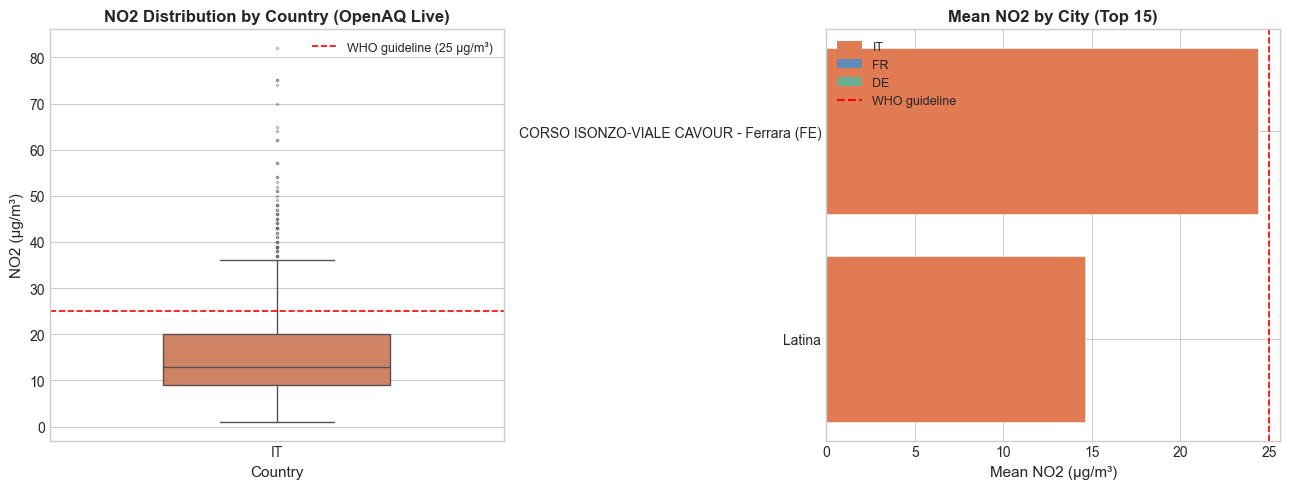


NO2 statistics by country (OpenAQ live data):
         count   mean  median    std    max
country                                    
IT         843 16.810  13.000 11.500 82.000


In [43]:
if len(df_oaq) == 0:
    print("No OpenAQ data available — skipping this section.")
    print("Re-run notebook 01_data_acquisition.ipynb to fetch fresh data.")
else:
    # Clean the values
    df_oaq["no2_value"] = pd.to_numeric(df_oaq["no2_value"], errors="coerce")
    df_oaq_clean = df_oaq.dropna(subset=["no2_value", "country"])

    # Filter to reasonable NO2 range (remove sensor errors)
    # WHO guideline for NO2 is 25 µg/m³ annual mean;
    # hourly values above 500 are almost certainly sensor errors
    df_oaq_clean = df_oaq_clean[
        (df_oaq_clean["no2_value"] >= 0) &
        (df_oaq_clean["no2_value"] <= 500)
    ]

    # ── Plot 1: Box plot of NO2 by country ────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    country_palette = {"IT": COLOR_CO, "FR": COLOR_NO2, "DE": COLOR_BEN}

    sns.boxplot(
        data=df_oaq_clean,
        x="country",
        y="no2_value",
        palette=country_palette,
        ax=axes[0],
        width=0.5,
        flierprops=dict(marker=".", markersize=3, alpha=0.4)
        # flierprops controls how outlier dots look
    )
    axes[0].set_title("NO2 Distribution by Country (OpenAQ Live)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Country", fontsize=11)
    axes[0].set_ylabel("NO2 (µg/m³)", fontsize=11)

    # Add the WHO reference line
    axes[0].axhline(25, color="red", linestyle="--", linewidth=1.2,
                    label="WHO guideline (25 µg/m³)")
    axes[0].legend(fontsize=9)

    # ── Plot 2: Mean NO2 per city (top 10 cities) ─────────────────
    city_means = (
        df_oaq_clean
        .groupby(["city", "country"])["no2_value"]
        .mean()
        .reset_index()
        # reset_index() turns the multi-level groupby index back into columns
        .dropna(subset=["city"])
        .sort_values("no2_value", ascending=True)
        .tail(15)   # Top 15 highest-NO2 cities
    )

    # Horizontal bar chart — easier to read city names
    bar_colors = [country_palette.get(c, "#888") for c in city_means["country"]]

    axes[1].barh(
        city_means["city"],       # y-axis: city names
        city_means["no2_value"],  # x-axis: mean NO2
        color=bar_colors,
        edgecolor="white",
        linewidth=0.4
    )
    axes[1].axvline(25, color="red", linestyle="--", linewidth=1.2, label="WHO guideline")
    axes[1].set_title("Mean NO2 by City (Top 15)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Mean NO2 (µg/m³)", fontsize=11)
    axes[1].legend(fontsize=9)

    # Add a legend for country colours manually
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k) for k, v in country_palette.items()]
    axes[1].legend(handles=legend_elements + [
        plt.Line2D([0],[0], color="red", linestyle="--", label="WHO guideline")
    ], fontsize=9)

    plt.tight_layout()
    plt.savefig("../outputs/02_openaq_country_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print summary stats per country
    print("\nNO2 statistics by country (OpenAQ live data):")
    print(
        df_oaq_clean.groupby("country")["no2_value"]
        .agg(["count", "mean", "median", "std", "max"])
        .round(2)
    )

In [44]:
print("=" * 60)
print("PHASE 2 EDA — Key Findings Summary")
print("=" * 60)

co_vals  = pd.to_numeric(df["CO(GT)"],  errors="coerce").dropna()
no2_vals = pd.to_numeric(df["NO2(GT)"], errors="coerce").dropna()

print(f"""
DATA HEALTH
  Rows:          {len(df):,}
  Date range:    {df['DateTime'].min().date()} → {df['DateTime'].max().date()}
  Most missing:  NMHC(GT) — will be dropped in Phase 3

DISTRIBUTIONS
  CO  skewness:  {co_vals.skew():.2f}  → right-skewed, log transform needed
  NO2 skewness:  {no2_vals.skew():.2f}  → moderately skewed

TIME PATTERNS
  CO peak hour:  {df.groupby('Hour')['CO_num'].mean().idxmax()}:00
  NO2 peak hour: {df.groupby('Hour')['NO2_num'].mean().idxmax()}:00
  Weekend effect: weekend mean CO = {df[df['IsWeekend']]['CO_num'].mean():.2f}
                  weekday mean CO  = {df[~df['IsWeekend']]['CO_num'].mean():.2f}

FEATURES TO ENGINEER IN PHASE 3
  → Hour, DayOfWeek, Month, IsWeekend (time features)
  → Lag_1h, Lag_3h, Lag_24h (previous-hour values)
  → Rolling_3h mean, Rolling_24h mean (smoothed context)
  → Log transforms of skewed pollutant columns
""")

print("\nCharts saved to outputs/:")
for f in sorted(os.listdir("../outputs")):
    if f.startswith("02_"):
        print(f"  {f}")

PHASE 2 EDA — Key Findings Summary

DATA HEALTH
  Rows:          9,357
  Date range:    2004-01-04 → 2005-12-03
  Most missing:  NMHC(GT) — will be dropped in Phase 3

DISTRIBUTIONS
  CO  skewness:  1.37  → right-skewed, log transform needed
  NO2 skewness:  0.62  → moderately skewed

TIME PATTERNS
  CO peak hour:  19.0:00
  NO2 peak hour: 19.0:00
  Weekend effect: weekend mean CO = 2.00
                  weekday mean CO  = 2.17

FEATURES TO ENGINEER IN PHASE 3
  → Hour, DayOfWeek, Month, IsWeekend (time features)
  → Lag_1h, Lag_3h, Lag_24h (previous-hour values)
  → Rolling_3h mean, Rolling_24h mean (smoothed context)
  → Log transforms of skewed pollutant columns


Charts saved to outputs/:
  02_boxplots_outliers.png
  02_correlation_heatmap.png
  02_hourly_patterns.png
  02_missing_values.png
  02_openaq_country_comparison.png
  02_pollutant_distributions.png
  02_seasonal_patterns.png
  02_sensor_vs_truth.png
  02_weekly_patterns.png
